In [1]:
from collections import Counter
from importlib import reload
from itertools import chain
import json
import math
import os
from pathlib import Path
from pprint import pprint
import sys

path = "/home/lk3591/Documents/code/RawByteClf"
os.chdir(path)
if path not in sys.path:
	sys.path.insert(0, path)

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import transformers

import src
reload(src)

from src.data.cfg import BODMAS_DIST_FILE, BODMAS_LABELS_FILE, DATASET_TO_FILES
from src.learn.train import get_config
from src.analysis import process_trainer_state, process_validation_reports
from src.utils import count_parameters, get_highest_path

/home/lk3591/anaconda3/envs/RawByteClf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/train.py'


2024-02-20 10:51:49,292	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-02-20 10:51:49,888	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/architectures/malconv.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/data/loaders_pt.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/helpers.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/utils.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/tokenization.py'


# These are plots for HRRFormer Top10 Classification using superpositional_scale_factor="log"

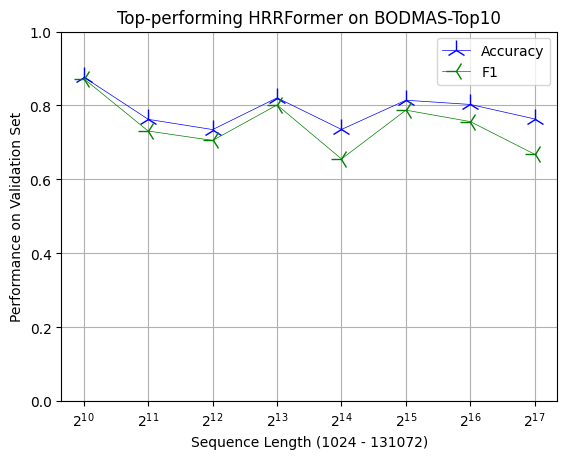

In [24]:
path = Path("./output/top10/hrrformer/")
sizes = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

data = {s: None for s in sizes}

for size in sizes:
    p = list((path / str(size)).rglob("checkpoints"))[0]
    f = get_highest_path(p, lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, train_reports = process_trainer_state(f)
    losses = np.array([r["eval_loss"] for r in validation_reports])
    # best_epoch = np.argmin(losses)
    best_epoch = np.argmax([r["eval_accuracy"] for r in validation_reports])
    loss = losses[best_epoch]
    acc = np.array([r["eval_accuracy"] for r in validation_reports])[best_epoch]
    f1 = np.array([r["eval_f1-macro"] for r in validation_reports])[best_epoch]
    data[size] = (loss, acc, f1)

#plt.plot(sizes, list(v[0] for v in data.values()), marker="1", label="Loss", color="red", linewidth=0.75)
plt.plot(sizes, list(v[1] for v in data.values()), marker="2", label="Accuracy", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in data.values()), marker="3", label="F1", color="green", linewidth=0.5, markersize=15)
plt.ylim(0, 1)
plt.xticks(sizes)
plt.xscale("log", base=2)
plt.xlabel("Sequence Length (1024 - 131072)")
plt.ylabel("Performance on Validation Set")
plt.title("Top-performing HRRFormer on BODMAS-Top10")
plt.legend()
plt.grid()

# These are plots for HRRFormer Top10 Classification using superpositional_scale_factor=1.0 and norm="forward"

output/top10/norm/hrrformer/1024 True
output/top10/norm/hrrformer/2048 True
output/top10/norm/hrrformer/4096 True
output/top10/norm/hrrformer/8192 True
output/top10/norm/hrrformer/16384 True
output/top10/norm/hrrformer/32768 True
output/top10/norm/hrrformer/65536 True


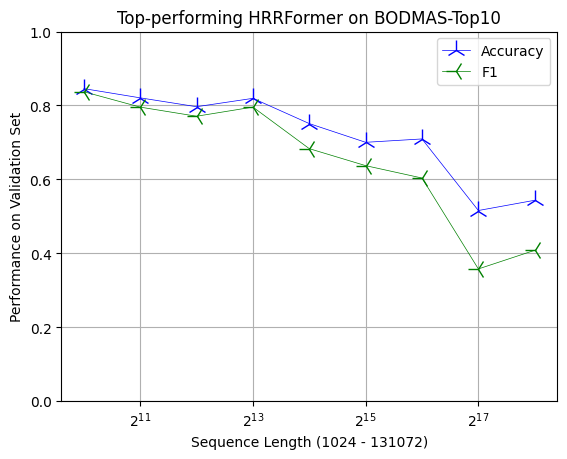

In [3]:
path = Path("./output/top10/norm/hrrformer")
sizes = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]

data = {s: None for s in sizes}

for size in sizes:
    if size == 131072:
        p = Path("/home/lk3591/Documents/code/RawByteClf/output/top10/norm/hrrformer/131072/clf/1/False/False/False/4a5ecc7b85055b3a/6cfac8a7dc321d19")
    elif size == 262144:
        p = Path("/home/lk3591/Documents/code/RawByteClf/output/top10/norm/hrrformer/262144/clf/1/False/False/False/2d292f87c92eddf9/3d16a32b5f736cd5")
    else:
        p = path / str(size)
        print(p, p.exists())

    c_path = list(p.rglob("checkpoints"))
    if c_path:
        p = c_path[0]
    else:
        continue

    f = get_highest_path(p, lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, train_reports = process_trainer_state(f)
    losses = np.array([r["eval_loss"] for r in validation_reports])
    # best_epoch = np.argmin(losses)
    best_epoch = np.argmax([r["eval_accuracy"] for r in validation_reports])
    loss = losses[best_epoch]
    acc = np.array([r["eval_accuracy"] for r in validation_reports])[best_epoch]
    f1 = np.array([r["eval_f1-macro"] for r in validation_reports])[best_epoch]
    data[size] = (loss, acc, f1)

#plt.plot(sizes, list(v[0] for v in data.values()), marker="1", label="Loss", color="red", linewidth=0.75)
plt.plot(sizes, list(v[1] for v in data.values()), marker="2", label="Accuracy", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in data.values()), marker="3", label="F1", color="green", linewidth=0.5, markersize=15)
plt.ylim(0, 1)
plt.xticks(sizes)
plt.xscale("log", base=2)
plt.xlabel("Sequence Length (1024 - 131072)")
plt.ylabel("Performance on Validation Set")
plt.title("Top-performing HRRFormer on BODMAS-Top10")
plt.legend()
plt.grid()

# Plots for MAMBA

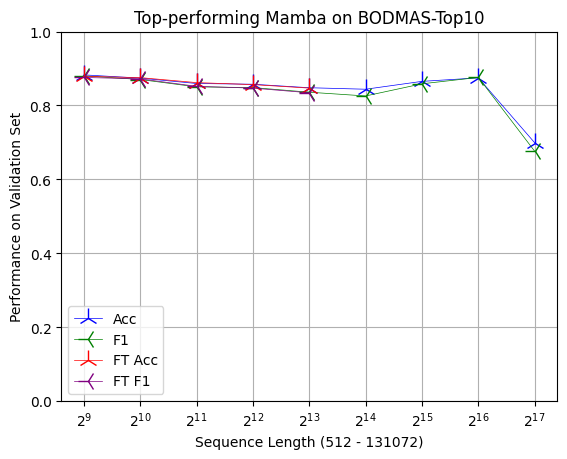

In [97]:
SIZES = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

root = Path("./output/mamba")

data = {}
finetuned = {}

best_epoch_metric = "eval_loss"

for size in SIZES:
    p_clf_10 = root / f"{size}/clf/None/10"
    p_checkpoints = list(p_clf_10.rglob("checkpoints"))
    p_trainer_state = get_highest_path(p_checkpoints[0], lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, _ = process_trainer_state(p_trainer_state)
    best_epoch = np.argmin([r[best_epoch_metric] for r in validation_reports])

    data[size] = (
        validation_reports[best_epoch]["eval_loss"],
        validation_reports[best_epoch]["eval_accuracy"],
        validation_reports[best_epoch]["eval_f1-macro"],
    )

    p_clm = root / f"{size}/clm/1"
    p_clf = list(p_clm.rglob("clf"))
    if len(p_clf) == 0:
        continue
    p_clf_10 = p_clf[0] / "None/10"
    p_checkpoints = list(p_clf_10.rglob("checkpoints"))

    if len(p_checkpoints) > 1:
        i = int(input(
            "Multiple checkpoints found. Select which path to use:\n"
            "\n".join([f"{i}: {p_checkpoints[i]}\n" for i in range(len(p_checkpoints))])
        ))
    else:
        p_checkpoint = p_checkpoints[0]

    p_trainer_state = get_highest_path(p_checkpoint, lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, _ = process_trainer_state(p_trainer_state)
    best_epoch = np.argmin([r[best_epoch_metric] for r in validation_reports])

    finetuned[size] = (
        validation_reports[best_epoch]["eval_loss"],
        validation_reports[best_epoch]["eval_accuracy"],
        validation_reports[best_epoch]["eval_f1-macro"],
    ) 

sizes = sorted(data.keys())
plt.plot(sizes, list(v[1] for v in data.values()), marker="2", label="Acc", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in data.values()), marker="3", label="F1", color="green", linewidth=0.5, markersize=15)

sizes = sorted(finetuned.keys())
plt.plot(sizes, list(v[1] for v in finetuned.values()), marker="2", label="FT Acc", color="red", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in finetuned.values()), marker="3", label="FT F1", color="purple", linewidth=0.5, markersize=15)


plt.ylim(0, 1)
plt.xscale("log", base=2)
plt.xticks(SIZES)
plt.xlabel("Sequence Length (512 - 131072)")
plt.ylabel("Performance on Validation Set")
plt.title("Top-performing Mamba on BODMAS-Top10")
plt.legend()
plt.grid()

{512: (3.0147018432617188, 4.333986282348633),
 1024: (3.371304988861084, 4.524545669555664),
 2048: (3.6425042152404785, 4.64689826965332),
 4096: (3.8398220539093018, 4.71075963973999),
 8192: (4.000156402587891, 4.769037246704102)}


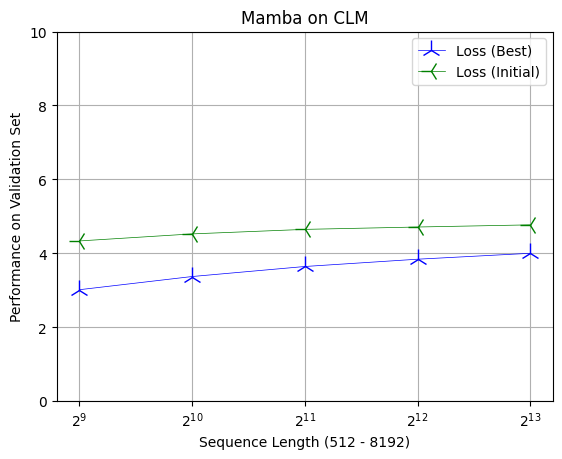

In [39]:
sizes = [512, 1024, 2048, 4096, 8192]

data = {s: None for s in sizes}

for size in sizes:
    p_clm_1 = root / f"{size}/clm/1"
    p_checkpoints = list(p_clm_1.rglob("checkpoints"))
    if len(p_checkpoints) > 1:
        p_checkpoints = [p for p in p_checkpoints if "clf" not in str(p)]

    if len(p_checkpoints) > 1:
        i = int(input(
            "Multiple checkpoints found. Select which path to use:\n"
            "\n".join([f"{i}: {p_checkpoints[i]}\n" for i in range(len(p_checkpoints))])
        ))
    else:
        p_checkpoint = p_checkpoints[0]
    p_trainer_state = get_highest_path(p_checkpoints[0], lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, _ = process_trainer_state(p_trainer_state)
    best_epoch = np.nanargmin([r[best_epoch_metric] for r in validation_reports])

    data[size] = (
        validation_reports[best_epoch]["eval_loss"],
        validation_reports[0]["eval_loss"],
    )


plt.plot(sizes, list(v[0] for v in data.values()), marker="2", label="Loss (Best)", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[1] for v in data.values()), marker="3", label="Loss (Initial)", color="green", linewidth=0.5, markersize=15)
plt.ylim(0, 10)
plt.xscale("log", base=2)
plt.xticks(sizes)
plt.xlabel("Sequence Length (512 - 8192)")
plt.ylabel("Performance on Validation Set")
plt.title("Mamba on CLM")
plt.legend()
plt.grid()

pprint(data)

In [ ]:
sizes = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

root = Path("./output/mamba")

data = {s: None for s in sizes}

best_epoch_metric = "eval_loss"

for size in sizes:
    p_clm = root / f"{size}/clm/1/"
    p_checkpoints = list(p_clf_10.rglob("checkpoints"))
    p_trainer_state = get_highest_path(p_checkpoints[0], lstrip="checkpoint-") / "trainer_state.json"
    validation_reports, _ = process_trainer_state(p_trainer_state)
    best_epoch = np.argmin([r[best_epoch_metric] for r in validation_reports])

    data[size] = (
        validation_reports[best_epoch]["eval_loss"],
        validation_reports[best_epoch]["eval_accuracy"],
        validation_reports[best_epoch]["eval_f1-macro"],
    )


plt.plot(sizes, list(v[1] for v in data.values()), marker="2", label="Accuracy", color="blue", linewidth=0.5, markersize=15)
plt.plot(sizes, list(v[2] for v in data.values()), marker="3", label="F1", color="green", linewidth=0.5, markersize=15)
plt.ylim(0, 1)
plt.xscale("log", base=2)
plt.xticks(sizes)
plt.xlabel("Sequence Length (512 - 131072)")
plt.ylabel("Performance on Validation Set")
plt.title("Top-performing Mamba on BODMAS-Top10")
plt.legend()
plt.grid()

# Dataset properties

Byte Distributions

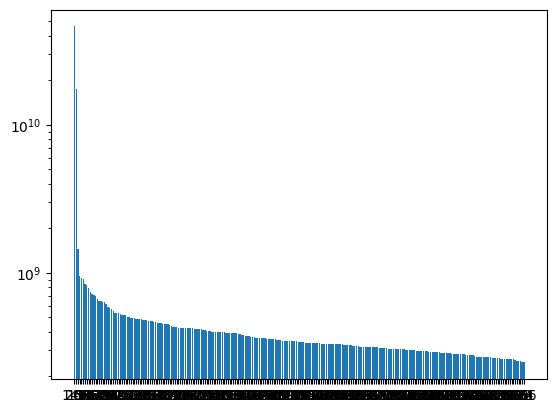

In [49]:
with open("tmp/byte_distribution.json") as fp:
    d = json.load(fp)

d = sorted(d.items(), key=lambda x: int(x[1]), reverse=True)
labels, counts = zip(*d)
plt.bar(labels, counts)
plt.yscale("log")

In [30]:
root = Path("/home/lk3591/Documents/datasets")

directories = list(
    d for d in (root / "VirusTotal").rglob("binaries")
    if (
        "binaries" in d.as_posix() and
        ("Win32_EXE" in d.as_posix() or "Win32_DLL" in d.as_posix()) and
        d.is_file(),
    )
)
directories = [root / "BODMAS/binaries"]

lengths = [f.stat().st_size for f in chain(*[d.iterdir() for d in directories])]

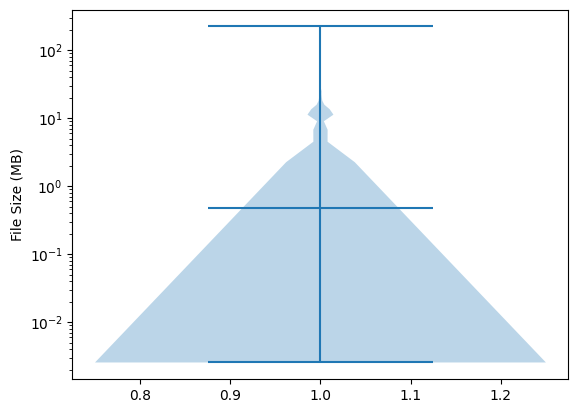

In [31]:
lengths = [l for l in lengths if l > 0]
plt.violinplot(np.array(lengths) / 1e6, showmeans=False, showextrema=True, showmedians=True)
plt.ylabel("File Size (MB)")
plt.yscale("log")
plt.show()


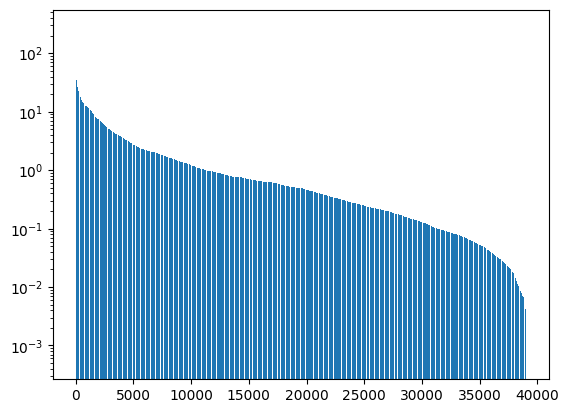

In [96]:
tmp = sorted(lengths, reverse=True)
tmp = [t for i, t in enumerate(tmp) if i % 10 == 0]
tmp = np.array(tmp) / 1e6
plt.bar(list(range(len(tmp))), tmp)
plt.yscale("log")

# Scaling Laws for Binary Language Models

In [10]:
def process(path: Path) -> tuple[int | float]:
    checkpoints_path = list(path.rglob("checkpoints"))
    if len(checkpoints_path) != 1:
        raise ValueError(path)
    checkpoints_path = checkpoints_path[0]
    last_checkpoint_path = get_highest_path(checkpoints_path, lstrip="checkpoint-")
    trainer_state_path = last_checkpoint_path / "trainer_state.json"
    validation_reports, train_reports = process_trainer_state(trainer_state_path)
    time_per_steps = [r["mean_time_per_step"] for r in train_reports]
    time_per_step = np.mean(time_per_steps)

    last_loss = [v["eval_loss"] for v in validation_reports][-1]

    with open(trainer_state_path, "r") as fp:
        best_loss = json.load(fp)["best_metric"]

    with open(checkpoints_path.parent / "initial_validation_results.json") as fp:
        first_loss = json.load(fp)["test_loss"]

    return (n_layer, d_model, n_params, best_loss, first_loss, last_loss, time_per_step)


MAMBA_CONFIGS = [
    (2, 512, 3526144),
    (2, 768, 7746816),
    (4, 384, 3958656),
    (4, 512, 6916608),
    (4, 768, 15290112),
    (6, 384, 5887104),
    (6, 512, 10307072),
    (6, 768, 22833408),
    (8, 256, 3571968),
    (8, 384, 7815552),
    (8, 512, 13697536),
    (8, 768, 30376704),
    (12, 192, 3071424),
    (12, 256, 5324032),
    (12, 384, 11672448),
    (12, 512, 20478464),
    (12, 768, 45463296),
    (16, 192, 4078272),
    (16, 256, 7076096),
    (16, 384, 15529344),
    (16, 512, 27259392),
    (16, 768, 60549888),
    (24, 192, 6091968),
    (24, 256, 10580224),
    (24, 384, 23243136),
    (24, 512, 40821248),
    (24, 768, 90723072),
    (28, 128, 3298944),
    (28, 192, 7098816),
    (28, 256, 12332288),
    (28, 384, 27100032),
    (28, 512, 47602176),
    (32, 128, 3765376),
    (32, 192, 8105664),
    (32, 256, 14084352),
    (32, 384, 30956928),
    (32, 512, 54383104),
]
HRR_CONFIGS = [
    (1, 512, 3815688),
    (1, 768, 8279304),
    (1, 1024, 14446856),
    (1, 2048, 56156424),
    (2, 512, 6968072),
    (2, 768, 15367176),
    (2, 1024, 27043080),
    (4, 256, 3425288),
    (4, 512, 13272840),
    (4, 768, 29542920),
    (4, 1024, 52235528),
    (6, 256, 5004808),
    (6, 512, 19577608),
    (6, 768, 43718664),
    (8, 256, 6584328),
    (8, 512, 25882376),
    (8, 768, 57894408),
    (10, 256, 8163848),
    (10, 512, 32187144),
    (10, 768, 72070152),
]

ROOT = Path("./output/scaling")

mamba_results = []
for n_layer, d_model, n_params in MAMBA_CONFIGS:
    path = ROOT / f"mamba/512/clm/1/d_model--{d_model}/n_layer--{n_layer}"
    mamba_results.append(process(path))
mamba_results = sorted(mamba_results, key=lambda x: x[2])

hrr_results = []
for n_layer, d_model, n_params in HRR_CONFIGS:
    path = ROOT / f"hrrformer/512/mlm/1/hidden_size--{d_model}/intermediate_size--{4 * d_model}/num_hidden_layers--{n_layer}"
    hrr_results.append(process(path))
hrr_results = sorted(hrr_results, key=lambda x: x[2])

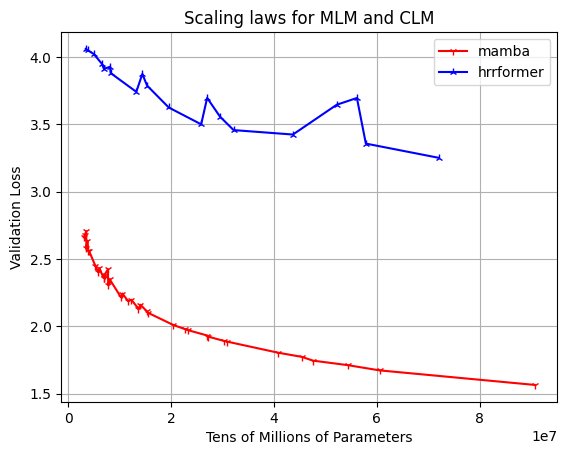

In [11]:
# (n_layer, d_model, n_params, best_loss, first_loss, last_loss, time_per_step)

x = [r[2] for r in mamba_results]
y = [r[3] for r in mamba_results]
plt.plot(x, y, color="red", marker="1", label="mamba")

x = [r[2] for r in hrr_results]
y = [r[3] for r in hrr_results]
plt.plot(x, y, color="blue", marker="2", label="hrrformer")

plt.xlabel("Tens of Millions of Parameters")
plt.ylabel("Validation Loss")
plt.title("Scaling laws for MLM and CLM")
plt.grid()
plt.legend()

In [25]:
# Divide width by depth; shorter fatter models come before deeper ones.
# sorted(hrr_results, key=lambda x: x[1] / x[0])
[(n_layer, d_model, best_loss) for (n_layer, d_model, n_params, best_loss, _, _, _) in hrr_results]
list(reversed(mamba_results))

[(24,
  768,
  90723072,
  1.564932942390442,
  6.874320030212402,
  1.564932942390442,
  10.652742210796902),
 (16,
  768,
  60549888,
  1.672968864440918,
  6.869661808013916,
  1.672968864440918,
  7.452412943840027),
 (32,
  512,
  54383104,
  1.711708426475525,
  5.894518852233887,
  1.711708426475525,
  8.930133696283614),
 (28,
  512,
  47602176,
  1.745364785194397,
  5.880280494689941,
  1.745364785194397,
  8.09914584466389),
 (12,
  768,
  45463296,
  1.7731362581253052,
  6.893659591674805,
  1.7731362581253052,
  5.672519825015749),
 (24,
  512,
  40821248,
  1.8043276071548462,
  5.884125232696533,
  1.8043276071548462,
  6.9268812326022555),
 (32,
  384,
  30956928,
  1.8862451314926147,
  5.710112571716309,
  1.8862451314926147,
  6.776487899848393),
 (8,
  768,
  30376704,
  1.8909283876419067,
  6.909542083740234,
  1.8909283876419067,
  5.392761929546084),
 (16,
  512,
  27259392,
  1.9233909845352173,
  5.881442070007324,
  1.9233909845352173,
  4.672025621277945),


In [21]:
top_k = 10
min_freq = 3
max_length = 2 ** 24

files = list(sorted(DATASET_TO_FILES["binaries"]["bodmas_pe"]()))
labels = pd.read_csv(BODMAS_LABELS_FILE).set_index("sha")["family"].to_dict()

files_and_labels = {
	f : labels[f.stem] for f in files
	if labels[f.stem] not in (np.NaN, "unknown", "Unknown")
	if f.stat().st_size <= max_length
}

# Filter out the files that are not in the top_k most frequent labels
dist: Counter[str, int] = Counter(files_and_labels.values())
keep = [l for l, n in dist.most_common(top_k) if (n >= min_freq)]
files_and_labels = {f: l for f, l in files_and_labels.items() if l in keep}

# Final collection of data items
dist: Counter[str, int] = Counter(files_and_labels.values())
label2id = {l: i for i, l in enumerate(dist.keys())}
id2label = {i: l for l, i in label2id.items()}

files = list(files_and_labels.keys())
labels = [label2id[files_and_labels[f]] for f in files]

In [24]:
LENGTHS = [2 ** 16, 2 ** 17, 2 ** 18, 2 ** 19, 2 ** 20, 2 ** 21, 2 ** 22, 2 ** 23, 2 ** 24]
dists = []
for length in LENGTHS:
    dists.append(Counter([l for f, l in files_and_labels.items() if f.stat().st_size <= length]))

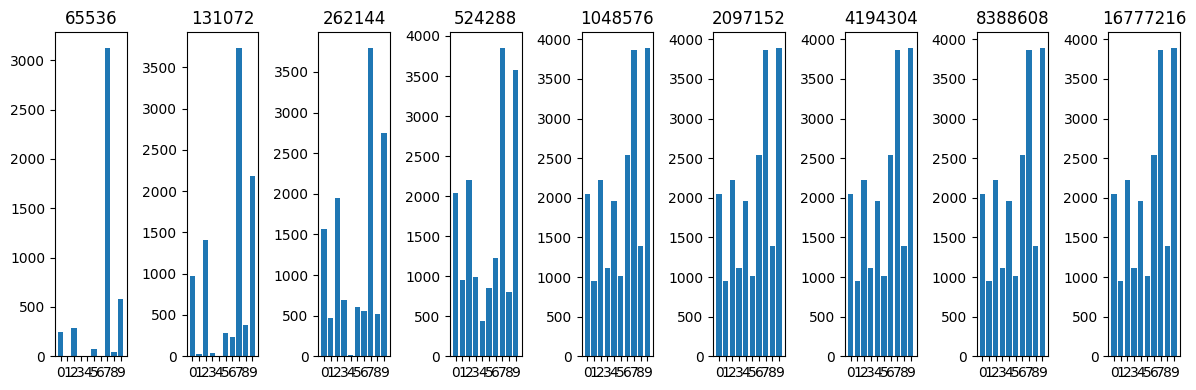

In [27]:
keys = sorted(set().union(*dists))

key_map = {k: str(i) for i, k in enumerate(keys)}

# Create subplots
num_plots = len(dists)
fig, axes = plt.subplots(1, num_plots, figsize=(12, 4))

# Plot histograms for each Counter
for i, (dist, length) in enumerate(zip(dists, LENGTHS)):
    data = [dist[key] for key in keys]
    axes[i].bar([key_map[k] for k in keys], data)
    axes[i].set_title(f'{length}')

plt.tight_layout()
plt.show()

In [3]:
p_0 = Path("/home/lk3591/Documents/code/RawByteClf/output/scaling/mamba/512/clf/None/None/False/False/False/d_model--768/n_layer--24/mlp_hidden_size--512/per_device_train_batch_size--128/gradient_accumulation_steps--1/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.98/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.0/bf16--True/fp16--False/tf32--True/optim--adamw_torch/")
p_1 = Path("/home/lk3591/Documents/code/RawByteClf/output/scaling/mamba/512/clm/1/d_model--768/n_layer--24/mlp_hidden_size--512/per_device_train_batch_size--128/gradient_accumulation_steps--16/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.98/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.05/bf16--True/fp16--False/tf32--True/optim--adamw_torch/checkpoints/checkpoint-1400/512/clf/None/None/False/False/False/per_device_train_batch_size--128/gradient_accumulation_steps--1/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.98/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.0/bf16--True/fp16--False/tf32--True/optim--adamw_torch/")

for p in [p_0, p_1]:
    f = get_highest_path(p / "checkpoints", lstrip="checkpoint-") / "trainer_state.json"
    report, _ = process_trainer_state(f)
    a = max(r["eval_accuracy"] for r in report)
    f = max(r["eval_f1-macro"] for r in report)
    l = min(r["eval_loss"] for r in report)
    print(a, f, l)

0.7618240379725377 0.6094019037011599 3.388035535812378
0.7557213086963892 0.6117859605067993 3.3804094791412354


# Scaling Laws for Mamba with Classification Performance

In [2]:
def process(path: Path) -> dict[str, float]:

    last_checkpoint_path = get_highest_path(path, lstrip="checkpoint-")
    trainer_state_path = last_checkpoint_path / "trainer_state.json"
    validation_reports, _ = process_trainer_state(trainer_state_path)

    metrics = ["eval_loss", "eval_accuracy", "eval_f1-macro"]
    lower_is_betters = [True, False, False]

    remove = []
    for i, m in enumerate(metrics):
        if m not in validation_reports[0]:
            remove.append(i)
    metrics = [m for i, m in enumerate(metrics) if i not in remove]
    lower_is_betters = [m for i, m in enumerate(lower_is_betters) if i not in remove]

    return process_validation_reports(validation_reports, metrics, lower_is_betters)


MAMBA_CONFIGS = [
    (2, 512, 3526144),
    (2, 768, 7746816),
    (4, 384, 3958656),
    (4, 512, 6916608),
    (4, 768, 15290112),
    (6, 384, 5887104),
    (6, 512, 10307072),
    (6, 768, 22833408),
    (8, 256, 3571968),
    (8, 384, 7815552),
    (8, 512, 13697536),
    (8, 768, 30376704),
    (12, 192, 3071424),
    (12, 256, 5324032),
    (12, 384, 11672448),
    (12, 512, 20478464),
    (12, 768, 45463296),
    (16, 192, 4078272),
    (16, 256, 7076096),
    (16, 384, 15529344),
    (16, 512, 27259392),
    (16, 768, 60549888),
    (24, 192, 6091968),
    (24, 256, 10580224),
    (24, 384, 23243136),
    (24, 512, 40821248),
    (24, 768, 90723072),
    (28, 128, 3298944),
    (28, 192, 7098816),
    (28, 256, 12332288),
    (28, 384, 27100032),
    (28, 512, 47602176),
    (32, 128, 3765376),
    (32, 192, 8105664),
    (32, 256, 14084352),
    (32, 384, 30956928),
    (32, 512, 54383104),
]

from pprint import pformat

ROOT = Path("./output/scaling/mamba")
paths = list(ROOT.rglob("checkpoints"))

results = []
for n_layer, d_model, n_params in MAMBA_CONFIGS:
    ps = [p for p in paths if f"/d_model--{d_model}/n_layer--{n_layer}/" in p.as_posix()]
    if not ps:
        print(f"/d_model--{d_model}/n_layer--{n_layer}/")
        continue

    p_clf = [p for p in ps if "clm" not in p.as_posix() and "clf" in p.as_posix()]
    if len(p_clf) > 1:
        p_clf = [p for p in p_clf if "per_device_train_batch_size--64" in p.as_posix()]
        if len(p_clf) > 1:
            raise ValueError(pformat(p_clf))
        else:
            p_clf = p_clf[0]
    else:
        p_clf = p_clf[0]
    p_clm = [p for p in ps if "clm" in p.as_posix() and "clf" not in p.as_posix()]

    if len(p_clm) > 1:
        raise ValueError(pformat(p_clm))
    else:
        p_clm = p_clm[0]
    p_ftclf = [p for p in ps if "clm" in p.as_posix() and "clf" in p.as_posix()]

    if len(p_ftclf) > 1:
        p_ftclf = [p for p in p_ftclf if "/clf/None/10/" in p.as_posix()]
        if len(p_ftclf) > 1:
            raise ValueError(pformat(p_ftclf))
        else:
            p_ftclf = p_ftclf[0]
    else:
        p_ftclf = p_ftclf[0]

    clf = process(p_clf)
    clm = process(p_clm)
    ftclf = process(p_ftclf)

    results.append((n_layer, d_model, n_params, clf, clm, ftclf))

results = sorted(results, key=lambda x: x[2])
x = [r[2] for r in results]

fig, ax1 = plt.subplots()

y = [r[4]["eval_loss"][0] for r in results]
ax1.plot(x, y, color="red", marker="1", label="clm")

ax1.set_xlabel("Tens of Millions of Parameters")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Scaling laws for MAMBA @512 bytes on BODMAS Top 10.")
ax1.grid()

ax2 = ax1.twinx()
y = [r[3]["eval_accuracy"][0] for r in results]
ax2.plot(x, y, color="blue", marker="2", label="clf")
y = [r[5]["eval_accuracy"][0] for r in results]
ax2.plot(x, y, color="green", marker="3", label="ftclf")
ax2.set_ylim(0.75, 1)
ax2.set_ylabel("Validation Accuracy")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

ValueError: [PosixPath('output/scaling/mamba/512/clf/None/10/False/False/False/d_model--512/n_layer--2/mlp_hidden_size--512/per_device_train_batch_size--64/gradient_accumulation_steps--1/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.999/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.0/bf16--True/fp16--False/tf32--True/optim--adamw_torch/checkpoints'),
 PosixPath('output/scaling/mamba/512/clf/None/None/False/False/False/d_model--512/n_layer--2/mlp_hidden_size--512/per_device_train_batch_size--64/gradient_accumulation_steps--1/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.999/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.0/bf16--True/fp16--False/tf32--True/optim--adamw_torch/checkpoints')]

In [ ]:
'output/scaling/mamba/512/clf/None/10/  False/False/False/d_model--512/n_layer--2/mlp_hidden_size--512/per_device_train_batch_size--64/gradient_accumulation_steps--1/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.999/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.0/bf16--True/fp16--False/tf32--True/optim--adamw_torch/checkpoints'
'output/scaling/mamba/512/clf/None/None/False/False/False/d_model--512/n_layer--2/mlp_hidden_size--512/per_device_train_batch_size--64/gradient_accumulation_steps--1/learning_rate--0.001/weight_decay--0.01/adam_beta1--0.9/adam_beta2--0.999/adam_epsilon--1e-08/max_grad_norm--1.0/lr_scheduler_type--linear/warmup_ratio--0.0/bf16--True/fp16--False/tf32--True/optim--adamw_torch/checkpoints'

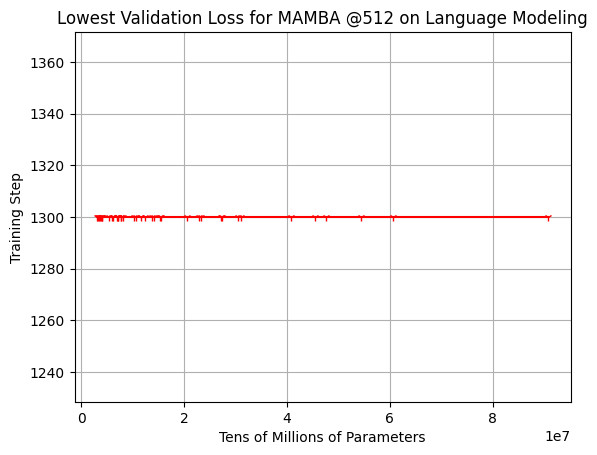

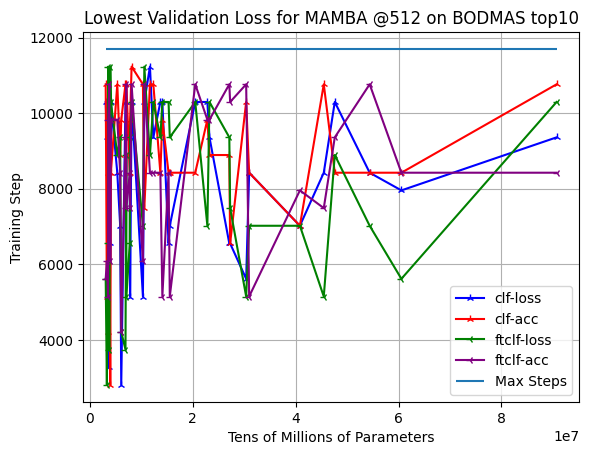

In [13]:
CLM_STEPS_PER_EVAL = 100
CLF_STEPS_PER_EVAL = 467.96875

y = [r[4]["eval_loss"][1] * CLM_STEPS_PER_EVAL for r in results]
plt.plot(x, y, color="red", marker="1", label="clm")

plt.xlabel("Tens of Millions of Parameters")
plt.ylabel("Training Step")
plt.title("Lowest Validation Loss for MAMBA @512 on Language Modeling")
plt.grid()
plt.show()

y = [r[3]["eval_loss"][1] * CLF_STEPS_PER_EVAL for r in results]
plt.plot(x, y, color="blue", marker="2", label="clf-loss")
y = [r[3]["eval_accuracy"][1] * CLF_STEPS_PER_EVAL for r in results]
plt.plot(x, y, color="red", marker="2", label="clf-acc")
y = [r[5]["eval_loss"][1] * CLF_STEPS_PER_EVAL for r in results]
plt.plot(x, y, color="green", marker="3", label="ftclf-loss")
y = [r[5]["eval_accuracy"][1] * CLF_STEPS_PER_EVAL for r in results]
plt.plot(x, y, color="purple", marker="3", label="ftclf-acc")
plt.xlabel("Tens of Millions of Parameters")
plt.ylabel("Training Step")
plt.title("Lowest Validation Loss for MAMBA @512 on BODMAS top10")
plt.grid()
plt.hlines(y=CLF_STEPS_PER_EVAL * 25, xmin=min(r[2] for r in results), xmax=max(r[2] for r in results), label="Max Steps")
plt.legend()
plt.show()

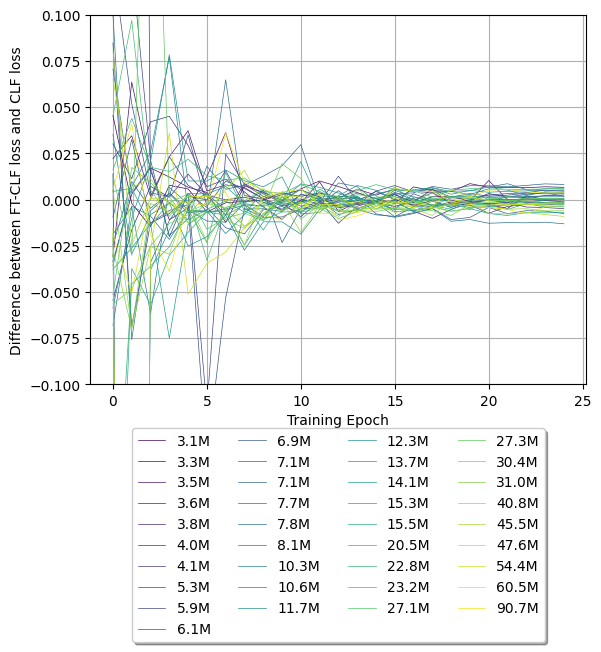

In [34]:
def process(path: Path) -> dict[str, float]:

    last_checkpoint_path = get_highest_path(path, lstrip="checkpoint-")
    trainer_state_path = last_checkpoint_path / "trainer_state.json"
    validation_reports, _ = process_trainer_state(trainer_state_path)
    return validation_reports


MAMBA_CONFIGS = [
    (2, 512, 3526144),
    (2, 768, 7746816),
    (4, 384, 3958656),
    (4, 512, 6916608),
    (4, 768, 15290112),
    (6, 384, 5887104),
    (6, 512, 10307072),
    (6, 768, 22833408),
    (8, 256, 3571968),
    (8, 384, 7815552),
    (8, 512, 13697536),
    (8, 768, 30376704),
    (12, 192, 3071424),
    (12, 256, 5324032),
    (12, 384, 11672448),
    (12, 512, 20478464),
    (12, 768, 45463296),
    (16, 192, 4078272),
    (16, 256, 7076096),
    (16, 384, 15529344),
    (16, 512, 27259392),
    (16, 768, 60549888),
    (24, 192, 6091968),
    (24, 256, 10580224),
    (24, 384, 23243136),
    (24, 512, 40821248),
    (24, 768, 90723072),
    (28, 128, 3298944),
    (28, 192, 7098816),
    (28, 256, 12332288),
    (28, 384, 27100032),
    (28, 512, 47602176),
    (32, 128, 3765376),
    (32, 192, 8105664),
    (32, 256, 14084352),
    (32, 384, 30956928),
    (32, 512, 54383104),
]

from pprint import pformat

ROOT = Path("./output/scaling/mamba")
paths = list(ROOT.rglob("checkpoints"))

results = []
for n_layer, d_model, n_params in MAMBA_CONFIGS:
    ps = [p for p in paths if f"/d_model--{d_model}/n_layer--{n_layer}/" in p.as_posix()]
    if not ps:
        print(f"/d_model--{d_model}/n_layer--{n_layer}/")
        continue

    p_clf = [p for p in ps if "clm" not in p.as_posix() and "clf" in p.as_posix()]
    if len(p_clf) > 1:
        p_clf = [p for p in p_clf if "per_device_train_batch_size--64" in p.as_posix()]
        if len(p_clf) > 1:
            raise ValueError(pformat(p_clf))
        else:
            p_clf = p_clf[0]
    else:
        p_clf = p_clf[0]
    p_clm = [p for p in ps if "clm" in p.as_posix() and "clf" not in p.as_posix()]

    if len(p_clm) > 1:
        raise ValueError(pformat(p_clm))
    else:
        p_clm = p_clm[0]
    p_ftclf = [p for p in ps if "clm" in p.as_posix() and "clf" in p.as_posix()]

    if len(p_ftclf) > 1:
        p_ftclf = [p for p in p_ftclf if "/clf/None/10/" in p.as_posix()]
        if len(p_ftclf) > 1:
            raise ValueError(pformat(p_ftclf))
        else:
            p_ftclf = p_ftclf[0]
    else:
        p_ftclf = p_ftclf[0]

    clf = process(p_clf)
    clm = process(p_clm)
    ftclf = process(p_ftclf)

    results.append((n_layer, d_model, n_params, clf, clm, ftclf))

results = sorted(results, key=lambda x: x[2])
x = list(range(25))

colormap = plt.cm.viridis

for i, res in enumerate(results):
    clf = np.array([r["eval_loss"] for r in res[3]])
    ftclf = np.array([r["eval_loss"] for r in res[5]])
    delta = ftclf - clf
    plt.plot(x, delta, label=f"{round(res[2] / 1e6, 1)}M", linewidth=0.5, color=colormap(i / len(results)))
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=4)
plt.ylabel("Difference between FT-CLF loss and CLF loss")
plt.xlabel("Training Epoch")
plt.grid()
plt.ylim(-0.1, 0.1)
plt.show()

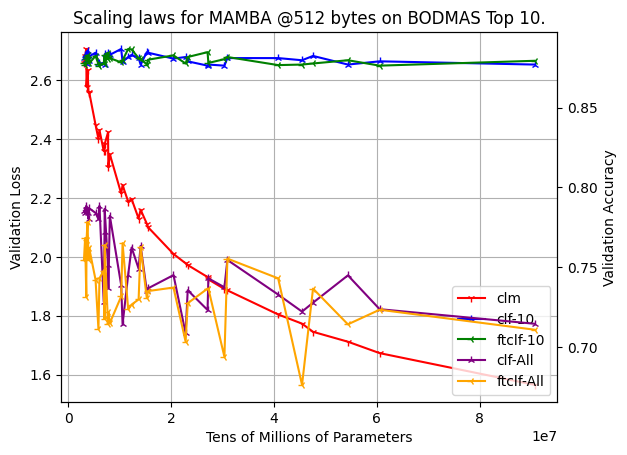

In [26]:
def process(path: Path) -> dict[str, float]:

    last_checkpoint_path = get_highest_path(path, lstrip="checkpoint-")
    trainer_state_path = last_checkpoint_path / "trainer_state.json"
    validation_reports, _ = process_trainer_state(trainer_state_path)

    metrics = ["eval_loss", "eval_accuracy", "eval_f1-macro"]
    lower_is_betters = [True, False, False]

    remove = []
    for i, m in enumerate(metrics):
        if m not in validation_reports[0]:
            remove.append(i)
    metrics = [m for i, m in enumerate(metrics) if i not in remove]
    lower_is_betters = [m for i, m in enumerate(lower_is_betters) if i not in remove]

    return process_validation_reports(validation_reports, metrics, lower_is_betters)


MAMBA_CONFIGS = [
    (2, 512, 3526144),
    (2, 768, 7746816),
    (4, 384, 3958656),
    (4, 512, 6916608),
    (4, 768, 15290112),
    (6, 384, 5887104),
    (6, 512, 10307072),
    (6, 768, 22833408),
    (8, 256, 3571968),
    (8, 384, 7815552),
    (8, 512, 13697536),
    (8, 768, 30376704),
    (12, 192, 3071424),
    (12, 256, 5324032),
    (12, 384, 11672448),
    (12, 512, 20478464),
    (12, 768, 45463296),
    (16, 192, 4078272),
    (16, 256, 7076096),
    (16, 384, 15529344),
    (16, 512, 27259392),
    (16, 768, 60549888),
    (24, 192, 6091968),
    (24, 256, 10580224),
    (24, 384, 23243136),
    (24, 512, 40821248),
    (24, 768, 90723072),
    (28, 128, 3298944),
    (28, 192, 7098816),
    (28, 256, 12332288),
    (28, 384, 27100032),
    (28, 512, 47602176),
    (32, 128, 3765376),
    (32, 192, 8105664),
    (32, 256, 14084352),
    (32, 384, 30956928),
    (32, 512, 54383104),
]

from pprint import pformat

ROOT = Path("./output/scaling/mamba")
paths = list(ROOT.rglob("checkpoints"))

results = []
for n_layer, d_model, n_params in MAMBA_CONFIGS:
    ps = [p for p in paths if f"/d_model--{d_model}/n_layer--{n_layer}/" in p.as_posix()]
    if not ps:
        print(f"/d_model--{d_model}/n_layer--{n_layer}/")
        continue

    p_clf = [p for p in ps if "clm" not in p.as_posix() and "clf" in p.as_posix()]
    p_clf = [p for p in p_clf if "per_device_train_batch_size--64" in p.as_posix()]
    if len(p_clf) < 2:
        raise FileNotFoundError(p_clf)
    if len(p_clf) > 2:
        raise FileExistsError(p_clf)
    p_clf_10 = [p for p in p_clf if "/clf/None/10/" in p.as_posix()][0]
    p_clf_None = [p for p in p_clf if "/clf/None/None/" in p.as_posix()][0]

    p_ftclf = [p for p in ps if "clm" in p.as_posix() and "clf" in p.as_posix()]
    p_ftclf = [p for p in p_ftclf if "per_device_train_batch_size--64" in p.as_posix()]
    if len(p_ftclf) < 2:
        raise FileNotFoundError(p_ftclf)
    if len(p_ftclf) > 2:
        raise FileExistsError(p_ftclf)
    p_ftclf_10 = [p for p in p_ftclf if "/clf/None/10/" in p.as_posix()][0]
    p_ftclf_None = [p for p in p_ftclf if "/clf/None/None/" in p.as_posix()][0]

    p_clm = [p for p in ps if "clm" in p.as_posix() and "clf" not in p.as_posix()]
    if len(p_clm) > 1:
        raise ValueError(p_clm)
    else:
        p_clm = p_clm[0]

    clm = process(p_clm)
    clf_10 = process(p_clf_10)
    ftclf_10 = process(p_ftclf_10)
    clf_None = process(p_clf_None)
    ftclf_None = process(p_ftclf_None)

    with open(p_clf_None.parent / "test_results/results.json", "rb") as fp:
        clf_None_test_results = json.load(fp)
    with open(p_ftclf_None.parent / "test_results/results.json", "rb") as fp:
        ftclf_None_test_results = json.load(fp)

    results.append(
        (
            n_layer,
            d_model,
            n_params,
            clm,
            clf_10,
            ftclf_10,
            clf_None,
            ftclf_None,
            clf_None_test_results,
            ftclf_None_test_results,
        )
    )

results = sorted(results, key=lambda x: x[2])
x = [r[2] for r in results]  # parameters
I_CLM = 3
I_CLF_10 = 4
I_FTCLF_10 = 5
I_CLF_NONE = 6
I_FTCLF_NONE = 7
I_CLF_NONE_TEST_RESULTS = 8
I_FTCLF_NONE_TEST_RESULTS = 9


fig, ax1 = plt.subplots()

y = [r[I_CLM]["eval_loss"][0] for r in results]
ax1.plot(x, y, color="red", marker="1", label="clm")

ax1.set_xlabel("Tens of Millions of Parameters")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Scaling laws for MAMBA @512 bytes on BODMAS Top 10.")
ax1.grid()

ax2 = ax1.twinx()
y = [r[I_CLF_10]["eval_accuracy"][0] for r in results]
ax2.plot(x, y, color="blue", marker="2", label="clf-10")
y = [r[I_FTCLF_10]["eval_accuracy"][0] for r in results]
ax2.plot(x, y, color="green", marker="3", label="ftclf-10")
y = [r[I_CLF_NONE]["eval_accuracy"][0] for r in results]
ax2.plot(x, y, color="purple", marker="2", label="clf-All")
y = [r[I_FTCLF_NONE]["eval_accuracy"][0] for r in results]
ax2.plot(x, y, color="orange", marker="3", label="ftclf-All")

# ax2.set_ylim(0.75, 1)
ax2.set_ylabel("Validation Accuracy")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

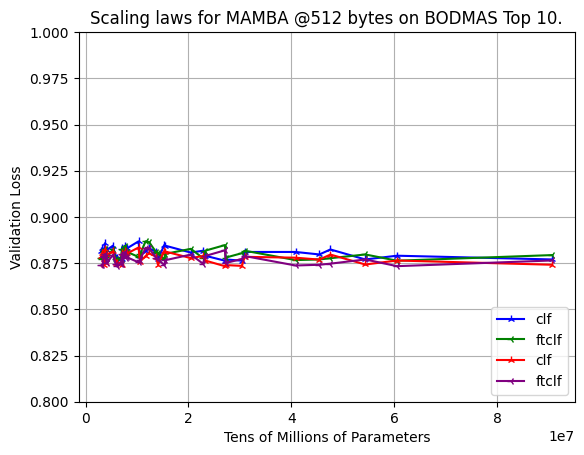

In [29]:
y = [r[I_CLF_10]["eval_accuracy"][0] for r in results]
plt.plot(x, y, color="blue", marker="2", label="clf")
y = [r[I_FTCLF_10]["eval_accuracy"][0] for r in results]
plt.plot(x, y, color="green", marker="3", label="ftclf")

y = [r[I_CLF_10]["eval_f1-macro"][0] for r in results]
plt.plot(x, y, color="red", marker="2", label="clf")
y = [r[I_FTCLF_10]["eval_f1-macro"][0] for r in results]
plt.plot(x, y, color="purple", marker="3", label="ftclf")

plt.ylabel("Validation Performance")
plt.legend(loc='lower right')
plt.ylim(0.8, 1.0)
plt.xlabel("Tens of Millions of Parameters")
plt.ylabel("Validation Loss")
plt.title("Scaling laws for MAMBA @512 bytes on BODMAS Top 10.")
plt.grid()

plt.show()

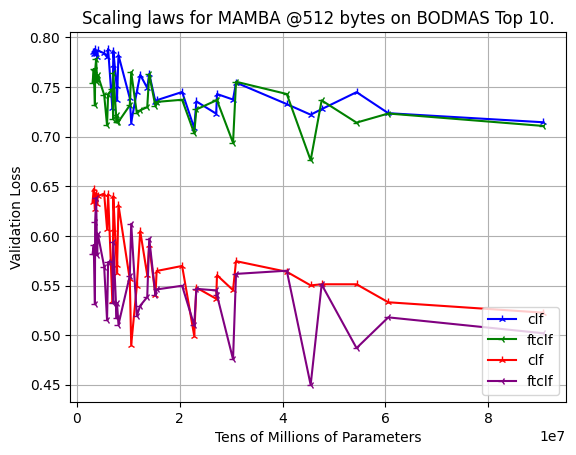

In [34]:
y = [r[I_CLF_NONE]["eval_accuracy"][0] for r in results]
plt.plot(x, y, color="blue", marker="2", label="clf")
y = [r[I_FTCLF_NONE]["eval_accuracy"][0] for r in results]
plt.plot(x, y, color="green", marker="3", label="ftclf")

y = [r[I_CLF_NONE]["eval_f1-macro"][0] for r in results]
plt.plot(x, y, color="red", marker="2", label="clf")
y = [r[I_FTCLF_NONE]["eval_f1-macro"][0] for r in results]
plt.plot(x, y, color="purple", marker="3", label="ftclf")

plt.ylabel("Validation Performance")
plt.legend(loc='lower right')
plt.xlabel("Tens of Millions of Parameters")
plt.ylabel("Validation Loss")
plt.title("Scaling laws for MAMBA @512 bytes on BODMAS Top 10.")
plt.grid()
plt.show()